<a href="https://colab.research.google.com/github/Julianmoralez/Retos-Colab/blob/Retos-Colab/Arbol_de_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Una entidad financiera (FINTECH) quiere implementar un modelo de árbol de decisión para mejorar la preaprobación de créditos de consumo de sus solicitantes de este tipo de créditos. Para este proceso vamos a utilizar las variables:
*

Caso de

Una entidad

decisión par

solicitantes

variables:
Edad: indica el numero de años que posee una persona, o el tiempo que usted lleva en el sistema financiero

Ingresos: Engloba todos los ingresos que recibe una persona ademas si posee salario mensual (USD)

Egresos:

Monto (EAD):

0.Se procede con la carga de las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

1. Se procede con la carga de los datos de trabajo

In [ ]:
nxl='/content/1. SolicitantesCrédito(USD).xlsx'
XDB=pd.read_excel(nxl,sheet_name=1)
display(XDB)
#XD para datos de entrada (edad,ingresos,egresos, monto(EDAD))
#yd salida/destacada (Preaprobado)

,Unnamed: 0,Edad,Genero,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,Egresos,Tipo de actividad,Tipo de vivienda,Total Activos,Total pasivos,Salario,Ingresos por arriendo,Ingresos por honorarios,Ingresos financieros,Otros ingresos,Gasto familiar,Gasto obligatorio,Gasto arriendo,Otros gastos,Monto (EAD),Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
0,1,38,NR,Casado,1,0,0,3,Bachiller,Ninguno,1356.14400,1685.622667,Independiente,Familiar,0.000000,0.000000,889.334889,0.000000,0.0,0.0,0.000000,0.000000,276.000000,0.0,0.0,625.562230,48,18.375890,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1,0.041659,582.478943,0.063702
1,2,51,NR,Separado,6,1,1,4,Técnico,Ninguno,286.01600,364.462000,Empleado,Propia,0.000000,0.000000,2.426889,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,140.031984,36,5.062492,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1,0.234951,479.839966,0.465636
2,3,37,Mujer,Casado,2,0,0,3,Tecnólogo,Indefinido,517.46325,629.208889,Independiente,Propia,523.681602,331.777778,47.476444,0.000000,0.0,0.0,0.000000,0.000000,125.111111,0.0,0.0,284.564492,36,10.287688,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0,0.170330,417.653107,0.290071
3,4,29,NR,Separado,1,0,0,2,Tecnólogo,Ninguno,473.27000,551.616889,Empleado,Arrendada,0.000000,0.000000,116.377556,220.666667,0.0,0.0,222.222222,0.000000,73.555556,0.0,0.0,309.647588,24,15.458878,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.201659,316.791107,0.278389
4,5,42,Mujer,Casado,3,4,4,2,Especializacion,Ninguno,750.09175,806.715778,Empleado,Familiar,0.000000,0.000000,260.106222,0.000000,0.0,0.0,0.000000,0.000000,9.333333,0.0,0.0,500.663578,24,24.995180,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.140929,441.809570,0.203359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5837,8372,48,Hombre,Separado,0,0,0,3,Tecnólogo,Fijo,1207.84800,753.801111,Empleado,Propia,0.000000,1950.000000,438.388667,0.000000,0.0,0.0,400.000000,0.000000,24.222222,0.0,0.0,748.041791,36,27.043503,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1,0.056132,550.980408,0.091441
5838,8374,31,Hombre,Soltero,2,0,0,5,Bachiller,Indefinido,1472.77200,953.812889,Empleado,Propia,0.000000,0.000000,371.964889,0.000000,0.0,0.0,0.000000,134.222222,0.000000,0.0,0.0,870.793819,48,25.579568,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1,0.035120,659.471375,0.066962
5839,8375,38,Hombre,Separado,0,0,0,3,Bachiller,Labor Contratada,773.01975,672.910667,Independiente,Arrendada,0.000000,0.000000,28.789111,0.000000,0.0,0.0,44.444444,0.000000,99.333333,0.0,0.0,594.947894,36,21.508792,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1,0.101976,465.011536,0.165936
5840,8376,43,Mujer,Casado,1,2,2,2,Tecnólogo,Ninguno,635.50175,780.691556,Independiente,Familiar,11803.145425,5555.555556,112.471333,0.000000,0.0,0.0,0.000000,0.000000,9.333333,0.0,0.0,305.580539,36,11.047468,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1,0.156707,423.237305,0.247763


In [ ]:
# Select columns by integer position
XD= XDB.iloc[:, [1, 10, 11, 25]].copy()
yd=XDB.iloc[:, [32]].copy()

# Rename columns for better readability
XD.rename(columns={'Monto (EAD)': 'Monto_Credito'}, inplace=True)

# Display the first 5 rows of the new DataFrame with selected columns
display(XD)

,Edad,Ingresos,Egresos,Monto_Credito
0,38,1356.14400,1685.622667,625.562230
1,51,286.01600,364.462000,140.031984
2,37,517.46325,629.208889,284.564492
3,29,473.27000,551.616889,309.647588
4,42,750.09175,806.715778,500.663578
...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791
5838,31,1472.77200,953.812889,870.793819
5839,38,773.01975,672.910667,594.947894
5840,43,635.50175,780.691556,305.580539


2. se procede con la implementacion del modelo del arbol

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd) #Aqui el modelo busca la relacion entrada/salida

#y que fue lo que hizo el modelo?
ydp=mar.predict(XD) #esto ees lo que pronostica el modelo
mar.score(XD,yd) #esta es la efectividad o exactitud de este modelo

0.7771311194796303

In [ ]:
# Generar la matriz de confusión
cm = confusion_matrix(yd, ydp)
display(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

array([[2301,  658],
       [ 644, 2239]])

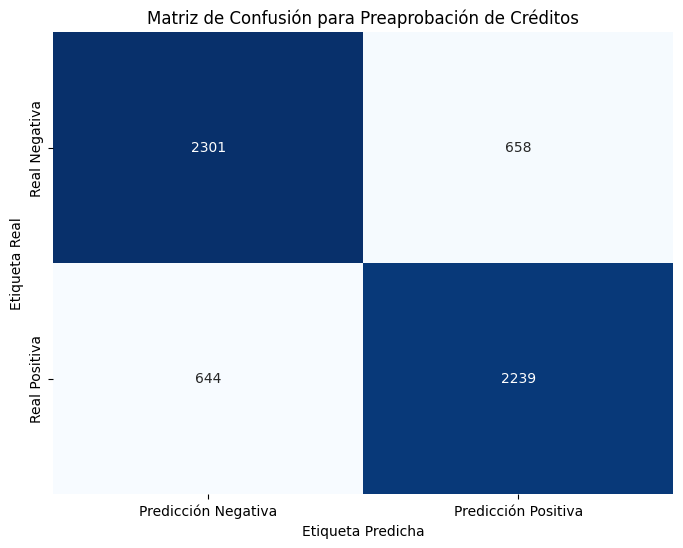

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener los valores de la matriz de confusión para etiquetas más descriptivas
tn, fp, fn, tp = cm.ravel()

# Crear etiquetas para el mapa de calor
labels = [['Verdaderos Negativos', 'Falsos Positivos'],
          ['Falsos Negativos', 'Verdaderos Positivos']]

# Crear una figura y un eje para el gráfico
plt.figure(figsize=(8, 6))

# Crear el mapa de calor
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicción Negativa', 'Predicción Positiva'],
            yticklabels=['Real Negativa', 'Real Positiva'])

# Añadir los títulos para un mejor entendimiento
plt.title('Matriz de Confusión para Preaprobación de Créditos')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

### Análisis de la Matriz de Confusión

La matriz de confusión resultante nos proporciona los siguientes valores:

*   **Verdaderos Negativos (VN):** 2301
*   **Falsos Positivos (FP):** 658
*   **Falsos Negativos (FN):** 644
*   **Verdaderos Positivos (VP):** 2239

**Interpretación Detallada:**

1.  **Verdaderos Positivos (VP = 2239):** Estos 2239 casos son los solicitantes que el modelo predijo correctamente que deberían recibir una preaprobación de crédito y que, de hecho, eran buenos candidatos. Esto es un indicador positivo de la capacidad del modelo para identificar oportunidades de negocio seguras.

2.  **Verdaderos Negativos (VN = 2301):** Aquí el modelo acertó al predecir que 2301 solicitantes no debían ser preaprobados, y efectivamente, no eran aptos. Esta capacidad es fundamental para la gestión de riesgos, ya que evita la exposición a posibles incumplimientos de pago.

3.  **Falsos Positivos (FP = 658):** Estos 658 casos representan a solicitantes que el modelo clasificó erróneamente como aptos para la preaprobación de crédito, cuando en realidad no lo eran. Cada uno de estos **Falsos Positivos implica un riesgo financiero** para la FINTECH, ya que se estaría otorgando un crédito a un individuo con alta probabilidad de no cumplir con sus obligaciones. Reducir los falsos positivos es crucial para minimizar las pérdidas.

4.  **Falsos Negativos (FN = 644):** En estos 644 casos, el modelo erró al rechazar a solicitantes que, en realidad, eran aptos para la preaprobación. Estos **Falsos Negativos representan oportunidades de negocio perdidas**. La FINTECH está dejando de conceder créditos rentables y, potencialmente, perdiendo clientes que podrían haber sido valiosos. Minimizar los falsos negativos es importante para maximizar el alcance y la rentabilidad del negocio.

**Conclusión General:**

El modelo exhibe un buen rendimiento general con una precisión del 77.71%. Sin embargo, la presencia de 658 Falsos Positivos y 644 Falsos Negativos indica áreas de mejora. La estrategia para optimizar el modelo dependerá de la prioridad del negocio: si se busca **minimizar el riesgo crediticio**, se enfocaría en reducir los Falsos Positivos (quizás ajustando el umbral de decisión); si se busca **maximizar la captación de clientes**, se priorizaría la reducción de los Falsos Negativos. Un análisis de los costos asociados a cada tipo de error (pérdida por un mal crédito vs. oportunidad perdida por un buen cliente rechazado) sería útil para tomar una decisión informada sobre los ajustes al modelo.

In [ ]:
# Calcular las métricas de desempeño

# Re-ajustar el modelo para asegurar que utiliza los nombres de características actualizados
mar.fit(XD,yd)

# La exactitud (accuracy) ya la tenemos del mar.score()
accuracy = mar.score(XD, yd)

# Precision: TP / (TP + FP)
precision = VP / (VP + FP)

# Recall (Exhaustividad/Sensibilidad): TP / (TP + FN)
recall = VP / (VP + FN)

# Especificidad (Specificity): VN / (VN + FP)
specificity = VN / (VN + FP)

# Predicción Negativa (Negative Predictive Value - NPV): VN / (VN + FN)
npv = VN / (VN + FN)

print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Especificidad (Specificity): {specificity:.4f}")
print(f"Predicción Negativa (NPV): {npv:.4f}")

Exactitud (Accuracy): 0.7771
Precisión (Precision): 0.7729
Sensibilidad (Recall): 0.7766
Especificidad (Specificity): 0.7776
Predicción Negativa (NPV): 0.7813


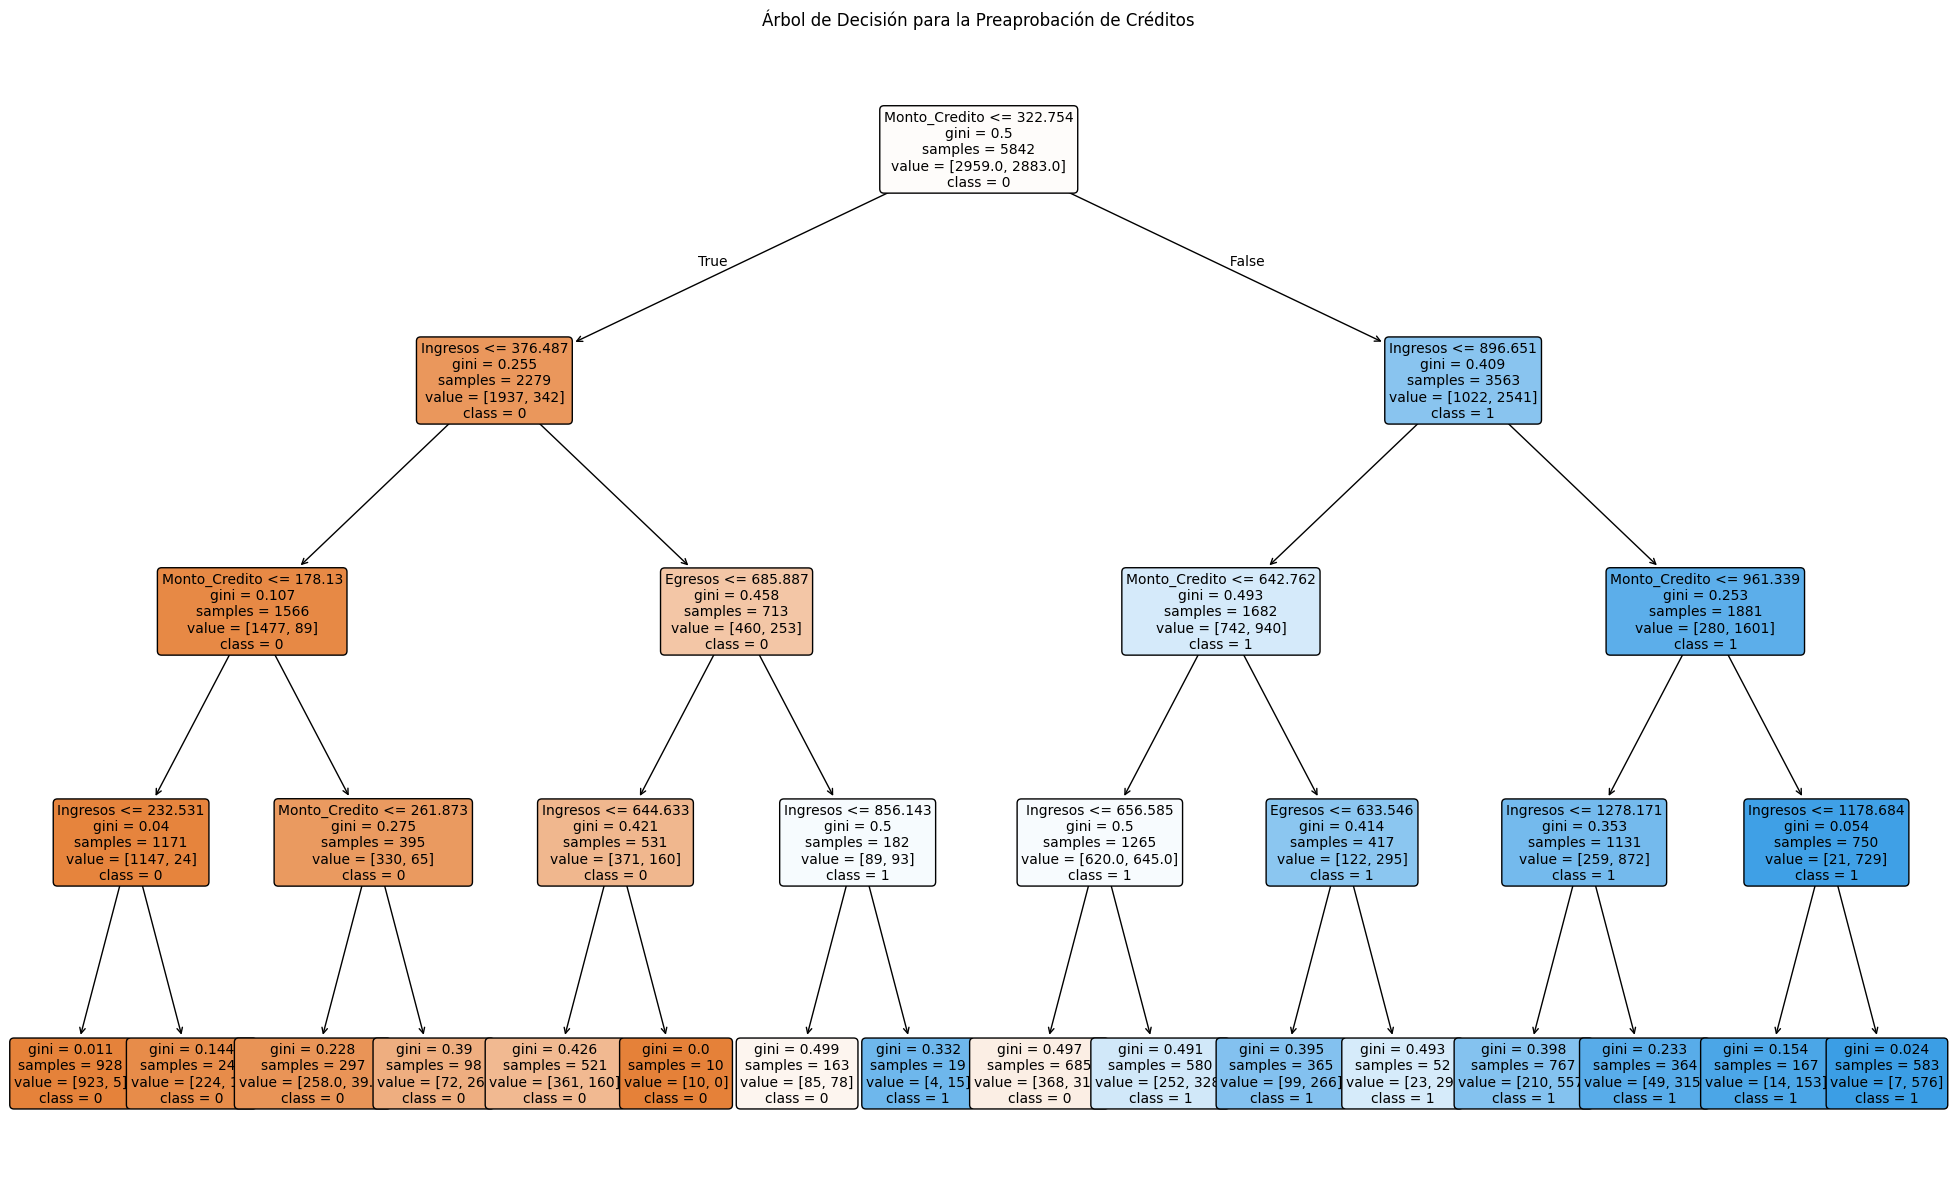

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Obtener los nombres de las características
feature_names = XD.columns.tolist()

# Obtener los nombres de las clases (Preaprobado o No Preaprobado)
class_names = [str(x) for x in sorted(yd['PreApr'].unique())] # Asumiendo que 'PreApr' es el nombre de la columna en yd

plt.figure(figsize=(25, 15)) # Ajusta el tamaño para que sea legible
plot_tree(mar, filled=True, feature_names=feature_names, class_names=class_names, rounded=True, fontsize=10)
plt.title('Árbol de Decisión para la Preaprobación de Créditos')
plt.show()

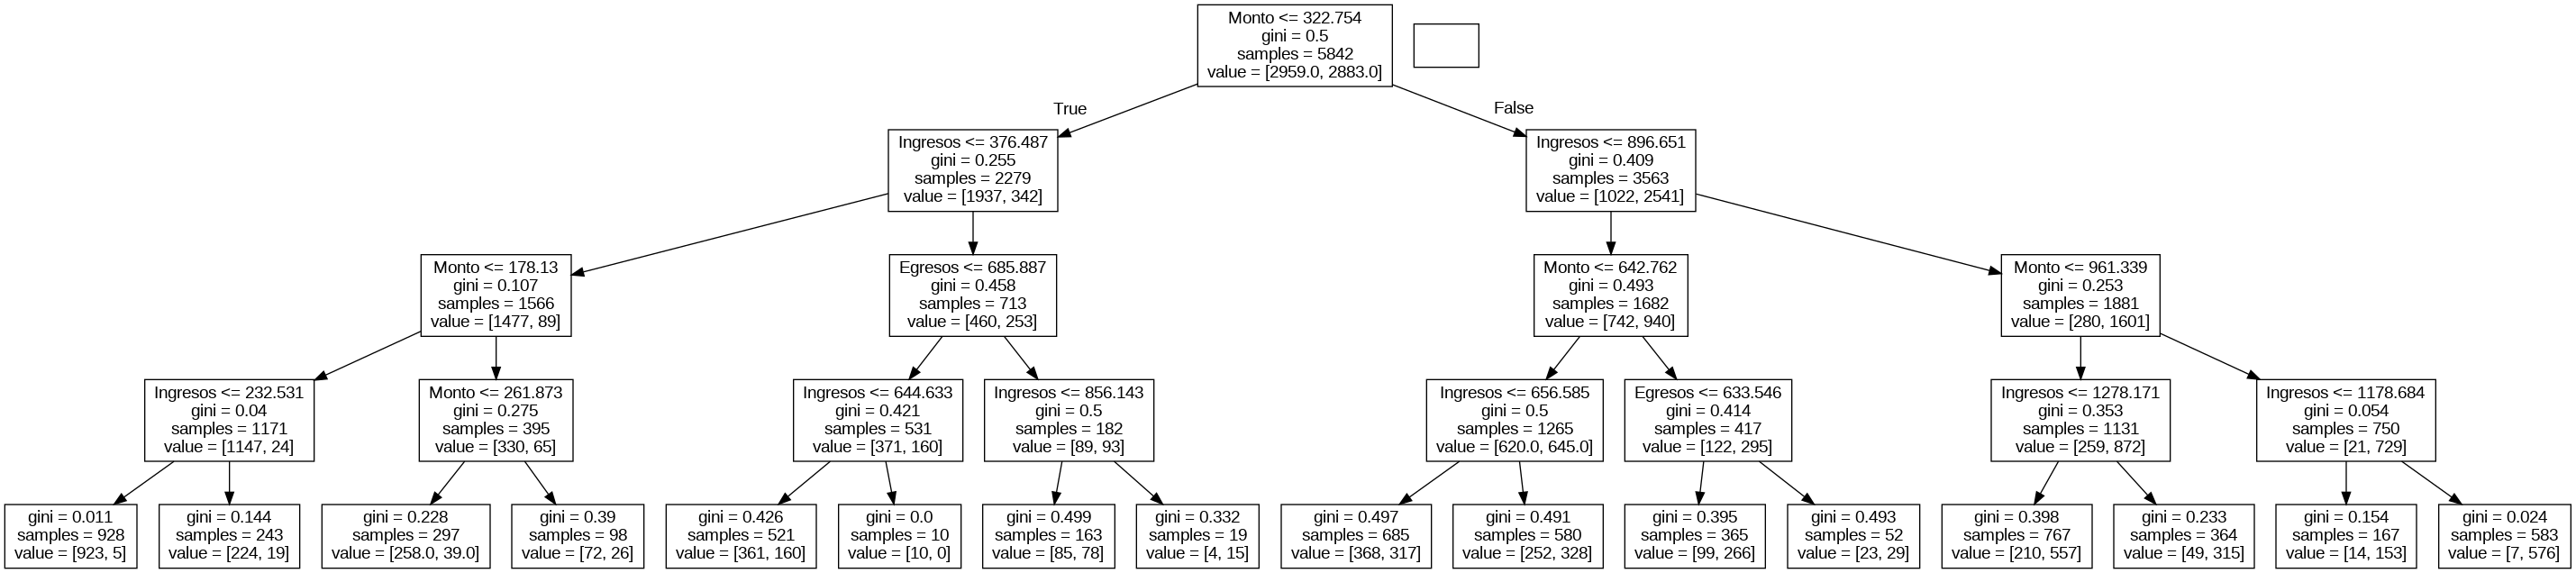

In [ ]:
#OTRA FORMA PARA HACERLO
from sklearn.tree import plot_tree
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz

# Obtener los nombres de las características
VS= ["Edad","Ingresos","Egresos","Monto"]

Dot_data=export_graphviz(mar,feature_names=VS)
graph=graph_from_dot_data(Dot_data)
graph.write_png('arbol.png')
from IPython.display import Image
Image('arbol.png')

### Análisis de las Métricas de Desempeño del Modelo de Árbol de Decisión:

*   **Exactitud (Accuracy: 0.7771):** El modelo clasifica correctamente al 77.71% de los solicitantes, lo que sugiere un rendimiento general aceptable. Sin embargo, la exactitud por sí sola puede ser engañosa en problemas donde las clases están desequilibradas (aunque aquí no parece ser el caso extremo, siempre es bueno ver otras métricas).

*   **Precisión (Precision: 0.7729):** Cuando el modelo predice que un solicitante debe ser preaprobado, tiene razón el 77.29% de las veces. Esta métrica es crucial para la FINTECH, ya que una precisión alta significa que se minimiza la cantidad de **Falsos Positivos**. Es decir, el modelo es relativamente bueno para evitar dar créditos a solicitantes que probablemente no pagarán, lo que reduce el riesgo financiero.

*   **Sensibilidad (Recall: 0.7766):** El modelo es capaz de identificar correctamente al 77.66% de todos los solicitantes que realmente son buenos candidatos para un crédito. Una alta sensibilidad es importante para maximizar la captación de clientes y evitar **Falsos Negativos**, es decir, no perder oportunidades de negocio al rechazar solicitantes que sí son aptos.

*   **Especificidad (Specificity: 0.7776):** El modelo identifica correctamente al 77.76% de los solicitantes que no son aptos para un crédito. Esto es importante para la gestión de riesgos, ya que asegura que la mayoría de los malos candidatos sean correctamente rechazados.

*   **Predicción Negativa (NPV: 0.7813):** Cuando el modelo predice que un solicitante NO debe ser preaprobado, tiene razón el 78.13% de las veces. Esta métrica complementa la precisión y es valiosa para confirmar la fiabilidad de las decisiones de rechazo, asegurando que un alto porcentaje de los rechazos son justificables.

**Conclusión General:**

El modelo demuestra un rendimiento equilibrado en todas las métricas. Los valores cercanos entre Precisión, Sensibilidad, Especificidad y Predicción Negativa, junto con una buena Exactitud, indican que el modelo no favorece excesivamente a una clase sobre otra. Esto es beneficioso para una FINTECH, ya que sugiere un balance entre la gestión del riesgo (evitar malos créditos) y la maximización de las oportunidades de negocio (identificar buenos clientes). El modelo parece ser una herramienta robusta para la preaprobación de créditos, aunque siempre hay margen para optimización según las prioridades estratégicas del negocio (por ejemplo, si se prefiere una mayor sensibilidad o una mayor precisión).

### Análisis Detallado de los Nodos del Árbol de Decisión:

Cada nodo en el árbol de decisión se compone de varias partes que nos brindan información crucial:

*   **Condición de División:** La primera línea de cada nodo (excepto los nodos hoja puros) muestra la característica y el valor umbral que utiliza el modelo para dividir los datos. Por ejemplo, `Monto <= 322.754`.
    *   Si un solicitante cumple con la condición (ej. su `Monto` es menor o igual a 322.754), sigue la rama `True` (generalmente a la izquierda).
    *   Si no cumple (ej. su `Monto` es mayor a 322.754), sigue la rama `False` (generalmente a la derecha).

*   **`gini` (Impureza de Gini):** Indica la 'pureza' del nodo. Un valor de Gini de `0` significa que todos los casos en ese nodo pertenecen a una sola clase (es un nodo hoja 'puro'). Un valor cercano a `0.5` indica que las clases están distribuidas de manera muy uniforme en ese nodo (máxima impureza).

*   **`samples` (Muestras):** Muestra el número total de solicitantes que llegan a ese nodo específico del árbol.

*   **`value` (Valor):** Es una lista que muestra la distribución de las clases en ese nodo. Por ejemplo, `[2959.0, 2883.0]` podría significar que hay 2959 solicitantes de la Clase 0 (no preaprobados) y 2883 de la Clase 1 (preaprobados) en ese nodo.

*   **`class` (Clase):** Para los nodos hoja, esta línea indica la clase mayoritaria o la predicción final para los solicitantes que llegan a ese nodo.

---

**Ejemplo de Recorrido del Árbol (Rutas de Decisión):**

Vamos a imaginar un par de rutas para entender cómo un solicitante específico sería clasificado:

1.  **Solicitante A: Monto_Credito = 200, Ingresos = 300, Edad = 40, Egresos = 100**
    *   **Nodo Raíz:** `Monto <= 322.754` (Verdadero, 200 <= 322.754). Sigue la rama izquierda.
    *   **Siguiente Nodo:** Probablemente será una condición sobre `Ingresos`. Si `Ingresos <= X` (Verdadero, 300 <= X), sigue la rama izquierda.
    *   ... Y así sucesivamente, hasta llegar a un nodo hoja que prediga `Preaprobado` o `No Preaprobado`.

2.  **Solicitante B: Monto_Credito = 500, Ingresos = 1500, Edad = 30, Egresos = 800**
    *   **Nodo Raíz:** `Monto <= 322.754` (Falso, 500 > 322.754). Sigue la rama derecha.
    *   **Siguiente Nodo:** ...

El árbol utiliza esta secuencia de preguntas sobre las características para segmentar a los solicitantes hasta que cada grupo (nodo hoja) es lo más homogéneo posible en términos de la clase de preaprobación.

---

**Observaciones Clave del Árbol:**

*   **Jerarquía de Importancia:** Como puedes ver, las variables que aparecen más arriba en el árbol (más cerca de la raíz) son las más importantes para clasificar a los solicitantes. En tu caso, `Monto_Credito` es el factor inicial más discriminante.
*   **Complejidad:** La profundidad del árbol (`max_depth=4` que especificaste) limita la complejidad, evitando un sobreajuste excesivo. Esto hace que el árbol sea más interpretable.
*   **Visualización de Segmentos:** Cada nodo te muestra cómo se distribuyen los solicitantes (número de `samples` y `value` para cada clase) según las condiciones que han cumplido hasta ese punto. Los nodos hoja te dan la predicción final para ese segmento de solicitantes.

A pesar de la no existencia de más nodos puros, se detacan los nodos extremos o las reglasdel negocio extremas. Se destaca una segunda regla que lograr un porcentaje de aprobación 99%, y la cula posee la siguiente estructura:
Si monto <= 322 and ing <=376
and Monto <=178 and ing <=232
(SON LOS DATOS DEL ARBOL)
por si parte el nodo derecho posee un porcentaje de negacion del 98%, en donde la regla se define:
Si monto >322 and ing>896
and Monto>961 and Ing>1178 (7/576)